# E337 - Grupo 1 - Trabajo Práctico 4
Integrantes: Constanza María Efkhanian - Julián Fabrizio Notario - María Florencia Pascale

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

# Limpieza previa

In [6]:
#  LIMPIEZA PREVIA 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

RUTA = r"C:\Users\HP\OneDrive\Documentos\Programación\E337_Grupo1\TP4"

df = pd.read_csv(f"{RUTA}/ocupados.csv")

# 1. Filtrar solo 2025
df25 = df[df['ANO4'] == 2025].copy().reset_index(drop=True)
print(f"Obs 2025: {len(df25)}")

# 2. Definir features
features = [
    # Demografía
    'CH03', 'CH04', 'CH06', 'CH07', 'CH08',
    'CH09', 'CH10', 'CH11', 'CH12', 'CH13',
    'CH15', 'CH16', 'NIVEL_ED', 'edad2',
    # Categoría ocupacional e intensidad
    'CAT_OCUP', 'INTENSI',
    # Horas y pluriempleo
    'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT',
    'PP03G', 'PP03H', 'PP03I', 'PP03J',
    # Ocupación principal
    'PP04A', 'PP04B1', 'PP04B2', 'PP04C', 'PP04G',
    # Beneficios laborales (aportes, aguinaldo, vacaciones, etc.)
    'PP07A', 'PP07C', 'PP07D', 'PP07E',
    'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5',
    'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59',
    'PP07H', 'PP07I', 'PP07J', 'PP07K',
    # Geografía
    'AGLOMERADO',
]

TARGET = 'informal'

# 3. Imputar missings menores con mediana (< 2% missing, solo PP3E_TOT, PP3F_TOT, CH07, CH08)
for col in features:
    n_miss = df25[col].isnull().sum()
    if n_miss > 0:
        mediana = df25[col].median()
        df25[col] = df25[col].fillna(mediana)
        print(f"  Imputado {col}: {n_miss} missings → mediana={mediana}")

# 4. Verificar sin missings
assert df25[features + [TARGET]].isnull().sum().sum() == 0, "Quedan missings!"
print(f"\nFeatures: {len(features)} | Obs: {len(df25)} | Informalidad: {df25[TARGET].mean():.3f}")

# 5. Train/test split (70/30)
X = df25[features]
y = df25[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} obs | Test: {len(X_test)} obs")
print(f"Informalidad train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

# 6. Guardar base limpia
ocupados_tp4 = df25[features + [TARGET]].copy()
ocupados_tp4.to_csv(f"{RUTA}/ocupados_tp4.csv", index=False)
print(f"\nGuardado: ocupados_tp4.csv  ({ocupados_tp4.shape[0]} obs × {ocupados_tp4.shape[1]} cols)")

Obs 2025: 3537
  Imputado CH07: 5 missings → mediana=2.0
  Imputado CH08: 4 missings → mediana=1.0
  Imputado PP3E_TOT: 48 missings → mediana=40.0
  Imputado PP3F_TOT: 10 missings → mediana=0.0

Features: 48 | Obs: 3537 | Informalidad: 0.262

Train: 2475 obs | Test: 1062 obs
Informalidad train: 0.261 | test: 0.262

Guardado: ocupados_tp4.csv  (3537 obs × 49 cols)


# Parte A: Modelo de Regresión Logística con Regularización: Ridge y LASSO

## 1. Visualización

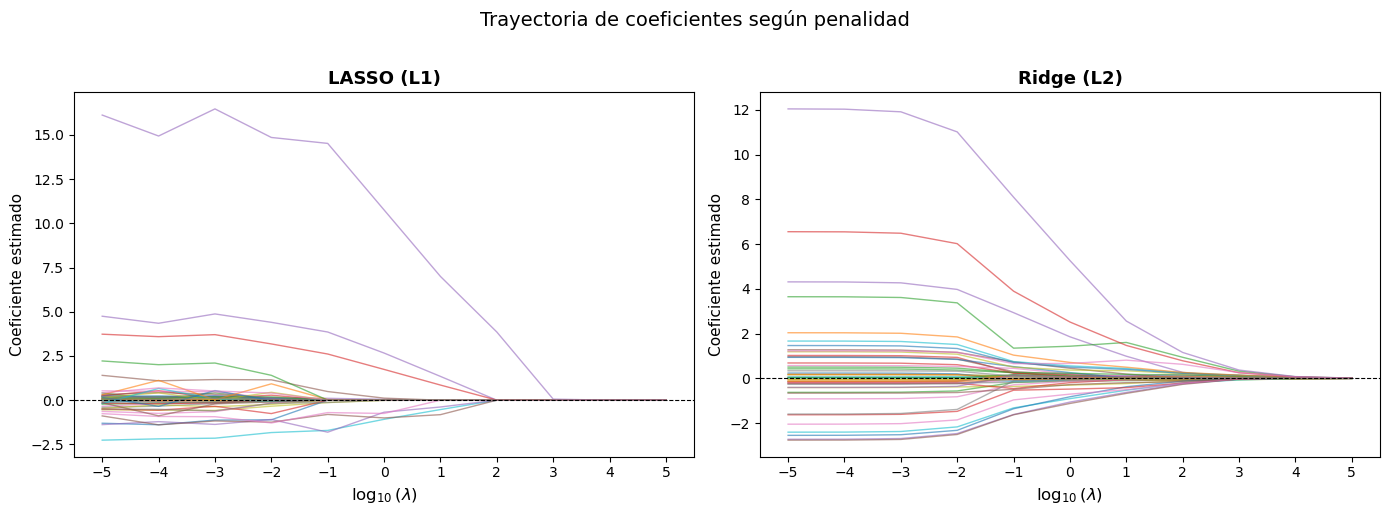

Guardado: A1_coeficientes.png


In [4]:
#  A.1 VISUALIZACIÓN DE COEFICIENTES RIDGE Y LASSO 

#Grid de lambdas = 10^n, n en {-5,...,5}
lambdas = 10**np.linspace(-5, 5, 11)

# Escalar X númericas
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

#loop
coefs_lasso = []
coefs_ridge = []

for lam in lambdas:
    C = 1 / lam 

    m_lasso = LogisticRegression(penalty='l1', C=C, solver='liblinear',
                                  fit_intercept=False, max_iter=1000)
    m_ridge = LogisticRegression(penalty='l2', C=C, solver='lbfgs',
                                  fit_intercept=False, max_iter=1000)
    m_lasso.fit(X_train_sc, y_train)
    m_ridge.fit(X_train_sc, y_train)

    coefs_lasso.append(m_lasso.coef_[0])
    coefs_ridge.append(m_ridge.coef_[0])

coefs_lasso = np.array(coefs_lasso)  # shape: (11, 48)
coefs_ridge = np.array(coefs_ridge)

# Graficamos 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, coefs, title in zip(
        axes,
        [coefs_lasso, coefs_ridge],
        ['LASSO (L1)', 'Ridge (L2)']):

    ax.plot(lambdas, coefs)          # una línea por variable
    ax.set_xscale("log")             # eje x en escala logarítmica
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda$ (escala log)', fontsize=12)
    ax.set_ylabel('Coeficientes', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('tight')

plt.suptitle('Trayectoria de coeficientes según penalidad', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{RUTA}/A1_coeficientes.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: A1_coeficientes.png")

## 2. Penalidad óptima por Cross-validation y visualización

## 3. Estimación con Lambda de Cross-Validation y comparación de coeficientes

# Parte B: Herramientas de IA y reflexión final

Realizado en documento de LaTeX. 